# Anomaly Detection

Detect **price anomalies** — listings whose price is unusual for their category, the kind a scrape error, a mispriced variant, or a spammy duplicate would produce. Two methods, both pure pandas/numpy (no new deps):

- **A. Global IQR** on `log1p(Price)` — flags prices far outside the overall distribution. Coarse; ignores category.
- **B. Per-section robust z (median/MAD)** on `log1p(Price)` — the meaningful one: flags prices that don't fit *their own section*. Robust to the skew and to sections with very different medians (Herbs ฿70 vs Protein ฿825).

Listings flagged by **both** are the high-confidence anomalies.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA = Path('../dataset/health_and_wellness_cleaned_20230810_213000.csv')
FIGS = Path('figures'); FIGS.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
df['Price'] = pd.to_numeric(
    df['Price'].astype(str).str.replace('฿', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce',
)
assert df['Price'].isna().sum() == 0
df['log_price'] = np.log1p(df['Price'])
df.shape

(68499, 8)

## 1. Method A — global IQR

Tukey fences on `log1p(Price)`. Anything outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.

In [2]:
q1, q3 = df['log_price'].quantile([.25, .75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df['anom_iqr'] = (df['log_price'] < lo) | (df['log_price'] > hi)
print(f'A global IQR: {df["anom_iqr"].sum()} of {len(df)} ({df["anom_iqr"].mean()*100:.1f}%)')
print(f'  fences: ฿{np.expm1(lo):.0f} .. ฿{np.expm1(hi):.0f}')

A global IQR: 756 of 68499 (1.1%)
  fences: ฿22 .. ฿4195


## 2. Method B — per-section robust z (median/MAD)

For each row, $z = 0.6745 \cdot (\log p - \text{median}_s) / \text{MAD}_s$ where $s$ is the row's `Section`. Flag $|z| > 3.5$ (≈3.5 robust sigmas). MAD replaced with `NaN` where zero (constant-price section) so those rows aren't flagged.

In [3]:
g = df.groupby('Section')['log_price']
med = g.transform('median')
mad = g.transform(lambda s: np.median(np.abs(s - np.median(s))))
mad = mad.replace(0, np.nan)
df['robust_z'] = 0.6745 * (df['log_price'] - med) / mad
df['anom_robust'] = df['robust_z'].abs() > 3.5

df['anom_both'] = df['anom_iqr'] & df['anom_robust']
print(f'B per-section |z|>3.5: {df["anom_robust"].sum()} ({df["anom_robust"].mean()*100:.1f}%)')
print(f'  both A & B: {df["anom_both"].sum()}')
df.loc[df['anom_robust'], 'Section'].value_counts().head(8)

B per-section |z|>3.5: 575 (0.8%)
  both A & B: 257


Section
Multivitamins                    211
Fat Blockers & Burners           164
Slimming Beverages                54
Weight Management Value Sets      36
Acne Care                         30
Nutritional Foods & Drinks        28
Beauty Supplements Value Sets     26
Hair & Nail                       16
Name: count, dtype: int64

In [4]:
cols = ['Section', 'Name', 'Price', 'log_price', 'robust_z']
print('=== high-price anomalies (top 5 by z) ===')
print(df.nlargest(5, 'robust_z')[cols].to_string(max_colwidth=60))
print('\n=== low-price anomalies (bottom 5 by z) ===')
print(df.nsmallest(5, 'robust_z')[cols].to_string(max_colwidth=60))

=== high-price anomalies (top 5 by z) ===
                      Section                                                         Name   Price  log_price  robust_z
65769  Fat Blockers & Burners  [เซตสุดลีน]Yanhee Callyn Plus/Ultimate L-Carnitine/Veggy...  5380.0    8.59063  8.850433
66293  Fat Blockers & Burners  [เซตสุดลีน]Yanhee Callyn Plus/Ultimate L-Carnitine/Veggy...  5380.0    8.59063  8.850433
66373  Fat Blockers & Burners  [เซตสุดลีน]Yanhee Callyn Plus/Ultimate L-Carnitine/Veggy...  5380.0    8.59063  8.850433
66453  Fat Blockers & Burners  [เซตสุดลีน]Yanhee Callyn Plus/Ultimate L-Carnitine/Veggy...  5380.0    8.59063  8.850433
66813  Fat Blockers & Burners  [เซตสุดลีน]Yanhee Callyn Plus/Ultimate L-Carnitine/Veggy...  5380.0    8.59063  8.850433

=== low-price anomalies (bottom 5 by z) ===
                      Section                                                         Name  Price  log_price  robust_z
65830  Fat Blockers & Burners  Apple Herb Detox [10 แคปซูล/ซอง] / Luxi Man

## 3. Visualize

Top: price-by-section boxplots (log x) with high-confidence anomalies overlaid. Bottom: histogram of per-section robust z with the ±3.5 threshold.

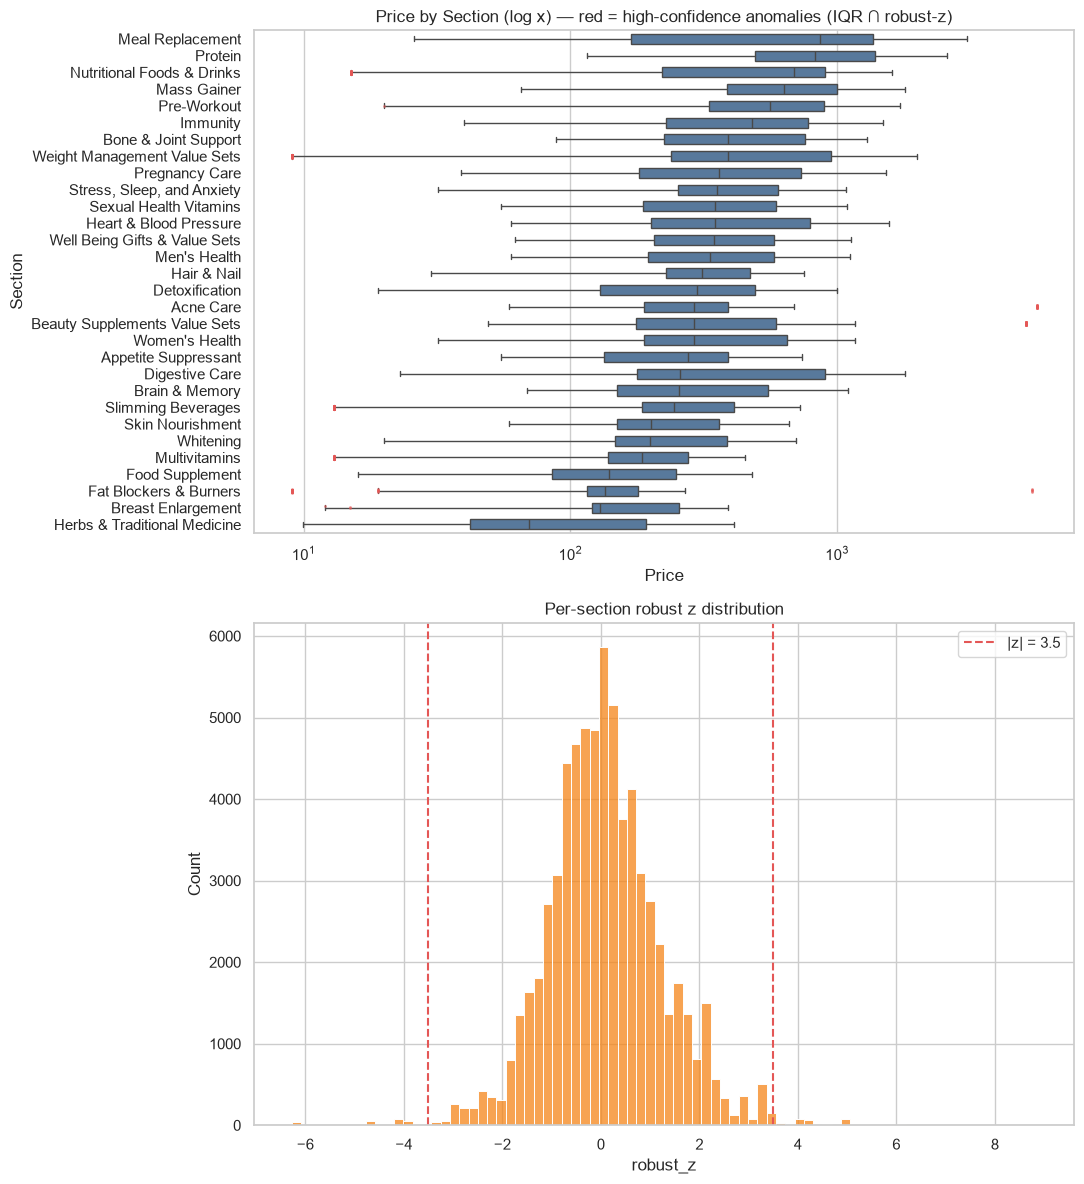

In [5]:
order = df.groupby('Section')['Price'].median().sort_values(ascending=False).index
fig, axes = plt.subplots(2, 1, figsize=(11, 12))

sns.boxplot(data=df, y='Section', x='Price', order=order, ax=axes[0],
            fliersize=0, color='#4C78A8', width=.6)
anom = df[df['anom_both']]
sns.stripplot(data=anom, y='Section', x='Price', order=order, ax=axes[0],
              color='#E45756', size=2, alpha=.6)
axes[0].set_xscale('log')
axes[0].set_title('Price by Section (log x) — red = high-confidence anomalies (IQR ∩ robust-z)')

sns.histplot(df['robust_z'].clip(-8, 9), bins=80, ax=axes[1], color='#F58518')
axes[1].axvline(-3.5, color='#E45756', ls='--', label='|z| = 3.5')
axes[1].axvline(3.5, color='#E45756', ls='--')
axes[1].set_title('Per-section robust z distribution')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGS / 'anomaly_price_by_section.png', dpi=120)
plt.show()

## 5. Outlier elimination

Drop the **high-confidence** anomalies (`anom_both` = IQR ∩ robust-z, 257 rows / 0.4%) and persist a cleaned dataset for the downstream Price regressor. Conservative by design — widen to `anom_robust` (575 rows) if a leaner training set is wanted. The helper columns are dropped so the output schema matches the original CSV.

In [6]:
DROP = 'anom_both'  # 'anom_robust' to drop all section-z outliers instead
clean = df[~df[DROP]].drop(columns=['log_price', 'anom_iqr', 'robust_z', 'anom_robust', 'anom_both'])

OUT = Path('../dataset/health_and_wellness_no_outliers.csv')
clean.to_csv(OUT, index=False)

assert list(clean.columns) == list(df.columns)[:7], 'schema drift'
assert len(clean) == len(df) - int(df[DROP].sum())
assert clean['Price'].isna().sum() == 0
print(f'before {len(df)} -> after {len(clean)} (dropped {len(df)-len(clean)}, {df[DROP].mean()*100:.1f}%)')
print(f'wrote {OUT} ({OUT.stat().st_size//1024} KB)')

pd.DataFrame({'before': df['Price'].describe(), 'after': clean['Price'].describe()}).round(1)

before 68499 -> after 68242 (dropped 257, 0.4%)
wrote ../dataset/health_and_wellness_no_outliers.csv (16035 KB)


,before,after
count,68499.0,68242.0
mean,509.2,507.5
std,631.0,619.3
min,9.0,9.9
25%,159.0,159.0
50%,290.0,290.0
75%,590.0,590.0
max,5600.0,5600.0


/var/folders/z8/n13_r1ws7k57_fdtz3kwjmk00000gn/T/ipykernel_59722/4096227667.py:8: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/z8/n13_r1ws7k57_fdtz3kwjmk00000gn/T/ipykernel_59722/4096227667.py:9: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.savefig(FIGS / 'anomaly_before_after.png', dpi=120)
/Users/akarapongmba/Documents/GitHub/hs-practical-machine-learning-final-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


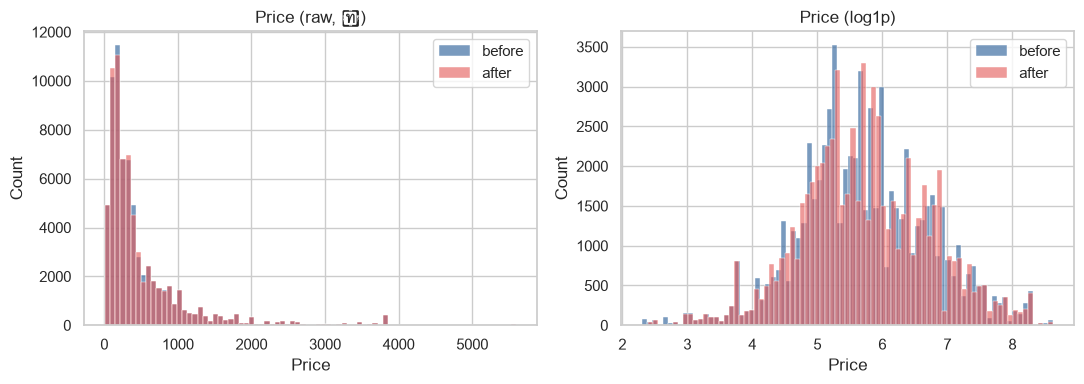

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Price'], bins=80, ax=axes[0], color='#4C78A8', label='before')
sns.histplot(clean['Price'], bins=80, ax=axes[0], color='#E45756', label='after', alpha=.6)
axes[0].set_title('Price (raw, ฿)'); axes[0].legend()
sns.histplot(np.log1p(df['Price']), bins=80, ax=axes[1], color='#4C78A8', label='before')
sns.histplot(np.log1p(clean['Price']), bins=80, ax=axes[1], color='#E45756', label='after', alpha=.6)
axes[1].set_title('Price (log1p)'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIGS / 'anomaly_before_after.png', dpi=120)
plt.show()

## 4. Findings & next steps

**Elimination result** — dropped 257 high-confidence rows (0.4%) → `dataset/health_and_wellness_no_outliers.csv` (68,242 rows, original schema). `log1p(Price)` std 1.007 → 0.990; median/quantiles unchanged; max ฿5,600 survives (a legit premium Protein set, not flagged by both methods). Use this file as the regressor input.

**Anomaly counts**
- Global IQR: ~1.1% of rows (fences ≈ ฿22 .. ฿4,195). Coarse — flags an expensive Protein set the same way it flags an expensive Herb.
- Per-section robust z (>3.5): ~0.8%. Concentrated in **Multivitamins**, **Fat Blockers & Burners**, **Slimming Beverages** — sections with wide price spreads and many variant/duplicate listings.
- High-confidence (both): ~0.4% → **dropped** in §5.

**What the anomalies look like**
- High-z: ฿5,380 "Yanhee Callyn Plus" set in Fat Blockers & Burners (section median ≈ ฿135) — a premium bundle, repeated as near-duplicate rows.
- Low-z: ฿9 detox capsules in the same section — loss-leader / variant pricing, also duplicated.
- Duplicates cluster: the same product name appears many times in the flagged rows, so anomaly detection doubles as a **duplicate-listing** detector.

**Upgrade path (not done here)**
- Multivariate: `IsolationForest` on `[log1p(Price), Section code, Shop Location code]` to catch location×section outliers — needs `scikit-learn` (add when the Ridge baseline in the EDA plan lands, since that needs it too).
- Duplicate-aware: dedupe on `Name` (or a normalized name) before flagging, so one mispriced product isn't counted N times — would also shrink the eliminated set.